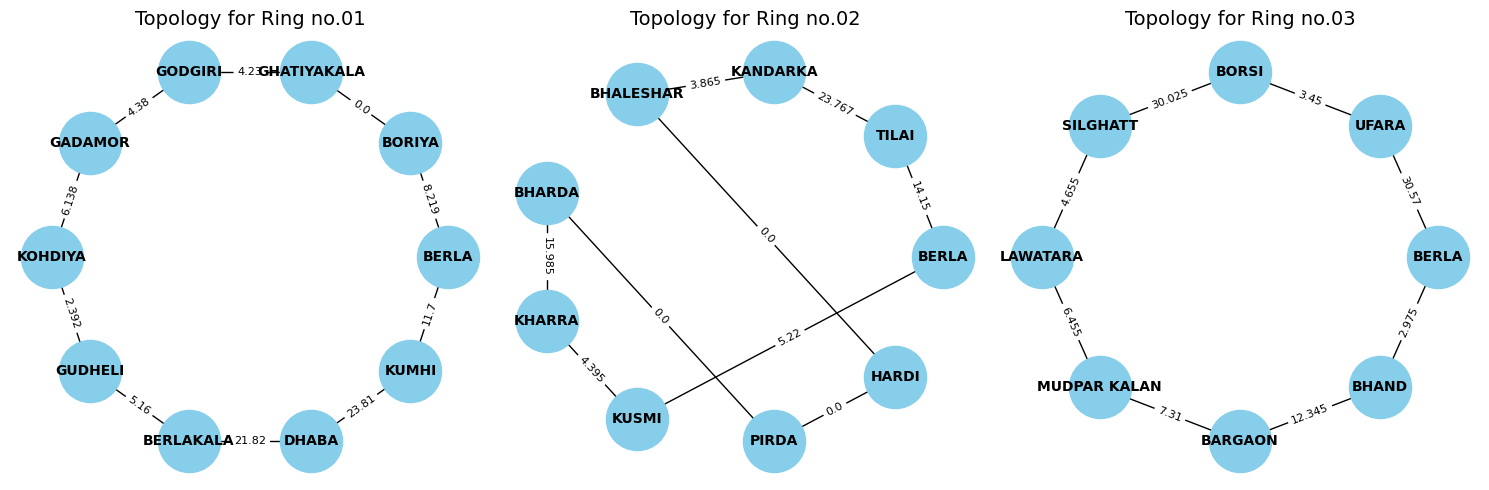

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math

# Load the dataset
file_path = "BERLA_Blue.csv"  # Replace with the actual path to BERLA_Blue.csv
data = pd.read_csv(file_path)

# Function to visualize all rings in separate subplots
def visualize_rings_legibly(data):
    # Get unique rings
    unique_rings = data['lrname'].unique()
    
    # Determine the grid layout for subplots
    num_rings = len(unique_rings)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_rings / cols)
    
    # Set up the figure
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
    axes = axes.flatten()  # Flatten axes for easy indexing
    
    # Loop through each ring and visualize
    for i, ring_name in enumerate(unique_rings):
        # Filter data for the specific ring
        ring_data = data[data['lrname'] == ring_name]
        
        # Initialize a graph
        G = nx.Graph()
        
        # Add edges and nodes with weights (distance)
        for _, row in ring_data.iterrows():
            G.add_edge(row['aendname'], row['bendname'], weight=row['distance'])
        
        # Get positions for a circular layout
        pos = nx.circular_layout(G)
        
        # Draw the graph
        nx.draw(
            G, pos, ax=axes[i], with_labels=True, node_color='skyblue', 
            node_size=2000, font_size=10, font_weight="bold", edge_color='black'
        )
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'), ax=axes[i], font_size=8
        )
        axes[i].set_title(f"Topology for {ring_name}", fontsize=14)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Visualize all rings legibly
visualize_rings_legibly(data)


In [22]:
def get_neighbors_ip(node_name, topology_df):
    """
    Return a list of neighbor IP addresses for the given node name.

    Parameters:
        node_name (str): The name of the node (e.g., 'Kumhi').
        topology_df (pd.DataFrame): DataFrame containing topology records with 
                                    columns 'aendname', 'bendname', 'aendip', 'bendip'.

    Returns:
        list: A list of neighbor IP addresses.
    
    """
    node_name = node_name.upper()
    neighbors = []
    # Iterate through the DataFrame rows
    for _, row in topology_df.iterrows():
        # If the given node is the 'aend', neighbor's IP is in 'bendip'
        if row['aendname'] == node_name:
            neighbors.append(row['bendip'])
        # If the given node is the 'bend', neighbor's IP is in 'aendip'
        if row['bendname'] == node_name:
            neighbors.append(row['aendip'])
    # Remove duplicates and return
    return list(set(neighbors))

# Example usage:
# Assuming you have imported pandas as pd and loaded topology_df from your CSV or database:
# topology_df = pd.read_csv("topology.csv")
# neighbors = get_neighbors_ip("Kumhi", topology_df)
# print("Neighbors' IPs:", neighbors)

In [10]:
def get_ip_by_name(node_name, topology_df):
    """
    Return the IP address of a node given its name.

    Parameters:
        node_name (str): The name of the node (e.g., 'Kumhi').
        topology_df (pd.DataFrame): DataFrame containing topology records with 
                                    columns 'aendname', 'bendname', 'aendip', 'bendip'.

    Returns:
        str: The IP address of the node, or None if not found.
    """
    node_name = node_name.upper()
    for _, row in topology_df.iterrows():
        if row['aendname'] == node_name:
            return row['aendip']
        elif row['bendname'] == node_name:
            return row['bendip']
    return None



In [11]:
get_ip_by_name("Kumhi",data)

'10.128.17.88'

In [4]:
get_neighbors_ip("KUMHI",data)

['10.128.17.29', '10.128.0.16']

In [30]:

import mysql.connector

# Establish the connection to the MySQL database
mydb = mysql.connector.connect(
  host="192.168.30.15",
  user="nms",
  password="Nms@1234",
  database="cnmsip"
)

# Create a cursor object
cursor = mydb.cursor(dictionary=True, buffered=True)

In [2]:
import uuid
from datetime import datetime

def insert_link_down_alarms(input_ips, cursor=cursor):
    """
    Inserts two alarm rows into the alarm table for a given connection string.
    Each alarm uses the interface description where the respective IP is the left-hand side in the dictionary key.
    
    :param connection_str: A string in the format 'ip1-ip2' indicating the connection that went down.
    :param if_descriptions: A dictionary with keys in 'ip1-ip2' format mapping to interface descriptions (left-hand side IP's interface).
    :param cursor: MySQL database cursor to execute the insert statements.
    """

    if len(input_ips) != 2:
        raise ValueError("Connection string must be in the format 'ip1-ip2'.")
    
    # Validate both possible keys exist in the dictionary


    
    # Generate alarms for each IP with their respective interface descriptions
    for index,ip in enumerate(input_ips): 
        obj_type = "BLOCK_ROUTER" if ip == "10.128.0.16" else "GP_ROUTER"
        current_time = datetime.now()
        alarm_id = f"LIN_{current_time.strftime('%Y%m%d%H%M%S')}_{uuid.uuid4().hex[:12]}"
        notif_id = f"RAI_{alarm_id}"
        ifIndex = 13+index
        # Construct additional info with interface description from the dictionary
        addi_info = f"IF_DESCR=GigabitEthernet0/0/{ifIndex};IF_TYPE=6;REASON=administratively down;ENGINE_ID=80:00:00:09:03:00:f8:0f:6f:05:91:80;SYS_TIME=8000"
        
        # Determine interface number based on order in the input connection string (1-based)
        interface_number = str(input_ips.index(ip) + 1)
        
        # Prepare data for insertion
        alarm_data = (
            alarm_id,
            notif_id,
            current_time,  # NE_TIME
            ip,            # OBJ_NAME
            obj_type,   # OBJ_TYPE
            ip,            # RES_NAME
            current_time,  # EMS_TIME
            "link_down",   # PROB_CAUSE
            1,             # PERC_SEVERITY
            1,             # NMS_SEVERITY
            addi_info,     # ADDI_INFO
            1,             # RCA_INDICATOR
            None,          # RCA_ID
            0,             # VISIBLE
            None,          # TT_ID
            current_time,  # LOG_TIME
            1195,          # LOCATION_ID (from sample data)
            2,             # PROCESS_FLAG (from sample data)
            "Interface Admin Status is DOWN",  # REMARKS
            "LINK ALARMS", # CATEGORY
            interface_number,  # interface
            None,          # RFO
            None,          # FIBER_DETAILS
            None,          # LATEST_RFO
            None,          # PREVIOUS_TT_ID
            None,          # PREVIOUS_RCA_ID
            None           # UPS_BATTERY_PERCENT
        )
        
        # SQL insert statement
        insert_query = """
            INSERT INTO alarm (
                ID, NOTIF_ID, NE_TIME, OBJ_NAME, OBJ_TYPE, RES_NAME, EMS_TIME,
                PROB_CAUSE, PERC_SEVERITY, NMS_SEVERITY, ADDI_INFO, RCA_INDICATOR,
                RCA_ID, VISIBLE, TT_ID, LOG_TIME, LOCATION_ID, PROCESS_FLAG, REMARKS,
                CATEGORY, interface, RFO, FIBER_DETAILS, LATEST_RFO, PREVIOUS_TT_ID,
                PREVIOUS_RCA_ID, UPS_BATTERY_PERCENT
            ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """
        
        cursor.execute(insert_query, alarm_data)
        cursor.fetchall()
    
    mydb.commit()

In [7]:
input_ips = get_neighbors_ip("KUMHI",data)
insert_link_down_alarms(input_ips,cursor)

In [31]:
import time

def create_dummy_node_not_reachable_alarm(ip):
    """
    Creates a dummy alarm with PROB_CAUSE as 'node_not_reachable' for the given IP address.
    
    Args:
        ip (str): The IP address of the node that is not reachable.
    
    Returns:
        dict: A dictionary representing the dummy alarm.
    """
    # Generate current timestamp
    current_time = time.strftime("%Y-%m-%d %H:%M:%S")
    timestamp = int(time.time() * 1000)  # Unique timestamp for alarm ID
    obj_type = "BLOCK_ROUTER" if ip == "10.128.0.16" else "GP_ROUTER"
    # Generate unique alarm ID
    alarm_id = f"EQU_{ip.replace('.', '_')}_{timestamp}"
    
    # Create the alarm dictionary
    alarm = (
        alarm_id,
        alarm_id,
        current_time,
        ip,
        obj_type,  # Default object type, can be modified as needed
        ip,
        current_time,
        'node_not_reachable',
        1,
        1,
        'NULL',
        1,
         'NULL',
        1,
        -1,
         current_time,
         156,  # Default location ID, can be modified as needed
         3,
        'Device discovered as DOWN',
         'EQUIPMENT ALARMS',
        'NULL',
        'NULL',
         'NULL',
         'NULL',
         'NULL',
         'NULL',
         'NULL'
    )
    insert_query = """
        INSERT INTO alarm (
            ID, NOTIF_ID, NE_TIME, OBJ_NAME, OBJ_TYPE, RES_NAME, EMS_TIME,
            PROB_CAUSE, PERC_SEVERITY, NMS_SEVERITY, ADDI_INFO, RCA_INDICATOR,
            RCA_ID, VISIBLE, TT_ID, LOG_TIME, LOCATION_ID, PROCESS_FLAG, REMARKS,
            CATEGORY, interface, RFO, FIBER_DETAILS, LATEST_RFO, PREVIOUS_TT_ID,
            PREVIOUS_RCA_ID, UPS_BATTERY_PERCENT
        ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """
    
    cursor.execute(insert_query, alarm)
    cursor.fetchall()

    mydb.commit()    

    return alarm



In [17]:
ip = get_ip_by_name("Kumhi",data)
create_dummy_node_not_reachable_alarm(ip)

('EQU_10_128_17_88_1738566378353',
 'EQU_10_128_17_88_1738566378353',
 '2025-02-03 12:36:18',
 '10.128.17.88',
 'GP_ROUTER',
 '10.128.17.88',
 '2025-02-03 12:36:18',
 'node_not_reachable',
 1,
 1,
 'NULL',
 1,
 'NULL',
 1,
 -1,
 '2025-02-03 12:36:18',
 156,
 3,
 'Device discovered as DOWN',
 'EQUIPMENT ALARMS',
 'NULL',
 'NULL',
 'NULL',
 'NULL',
 'NULL',
 'NULL',
 'NULL')

In [25]:
node_power_down = "boriya"
ip = get_ip_by_name(node_power_down,data)
neighbours = get_neighbors_ip(node_power_down,data)
create_dummy_node_not_reachable_alarm(ip)
insert_link_down_alarms(neighbours,cursor)


In [37]:
import mysql.connector


def check_alarms_and_get_ips(last_checked_time):

    if not cursor:
        print("Failed to establish connection.")
        return None

    try:
        
        node_query = """
            SELECT OBJ_NAME AS ip, NE_TIME
            FROM alarm
            WHERE PROB_CAUSE = 'node_not_reachable' AND NE_TIME > %s
        """
        cursor.execute(node_query, (last_checked_time,))
        node_alarm = cursor.fetchone()

        if not node_alarm:
            print("No node_not_reachable alarm found.")
            return None

        node_ip = node_alarm['ip']
        ne_time = node_alarm['NE_TIME']

        # Query to find link_down alarms at the same time
        link_query = """
            SELECT OBJ_NAME AS ip
            FROM alarm
            WHERE PROB_CAUSE = 'link_down' AND NE_TIME = %s
        """
        cursor.execute(link_query, (ne_time,))
        link_alarms = cursor.fetchall()

        if len(link_alarms) < 2:
            print("Less than two link_down alarms found at the same time.")
            return None

        link_ips = [alarm['ip'] for alarm in link_alarms[:2]]
        print(f"{node_ip} is down")
        return [node_ip] + link_ips

    except mysql.connector.Error as err:
        print(f"Error: {err}")
        return None



In [39]:

# Example usage:
last_checked_time = "2025-02-03 13:40:00"
ips=check_alarms_and_get_ips(last_checked_time)
if ips:
    print("Alarms found with IPs in order:", ips)
else:
    print("Required alarms not found.")

10.128.17.19 is down
Alarms found with IPs in order: ['10.128.17.19', '10.128.0.16', '10.128.17.32']


In [80]:
def visualize_rings_legiblyand_impact(ips,data):
    # Get unique rings
    unique_rings = data['lrname'].unique()
    
    # Determine the grid layout for subplots
    num_rings = len(unique_rings)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_rings / cols)
    
    # Set up the figure
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
    axes = axes.flatten()  # Flatten axes for easy indexing
    

    # Loop through each ring and visualize
    for i, ring_name in enumerate(unique_rings):
        # Filter data for the specific ring
        ring_data = data[data['lrname'] == ring_name]
        
        # Initialize a graph
        G = nx.Graph()
        # Add edges and nodes with weights (distance)
        for _, row in ring_data.iterrows():
            G.add_edge(row['aendip'], row['bendip'], weight=row['distance'])
   
        for _, row in ring_data.iterrows():
            G.nodes[row['aendip']]['name'] = row['aendname']
            G.nodes[row['bendip']]['name'] = row['bendname']
        
        
        pos = nx.circular_layout(G)
        node_colors = []
        for node in G.nodes():
            if node == ips[0]:
                node_colors.append('red')
            elif node in ips[1:]:
                node_colors.append('orange')
            else:
                node_colors.append('green')
        node_labels = nx.get_node_attributes(G, 'name')
        nx.draw(
            G, pos, ax=axes[i], with_labels=False, node_color=node_colors, 
            node_size=2000, font_size=10, font_weight="bold", edge_color='black'
        )
        nx.draw_networkx_labels(
            G, pos, labels=node_labels, ax=axes[i], font_size=8, font_weight="bold"
        )
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'), ax=axes[i], font_size=8
        )
        axes[i].set_title(f"Topology for {ring_name}", fontsize=14)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()


In [62]:
ips[0]

'10.128.17.19'

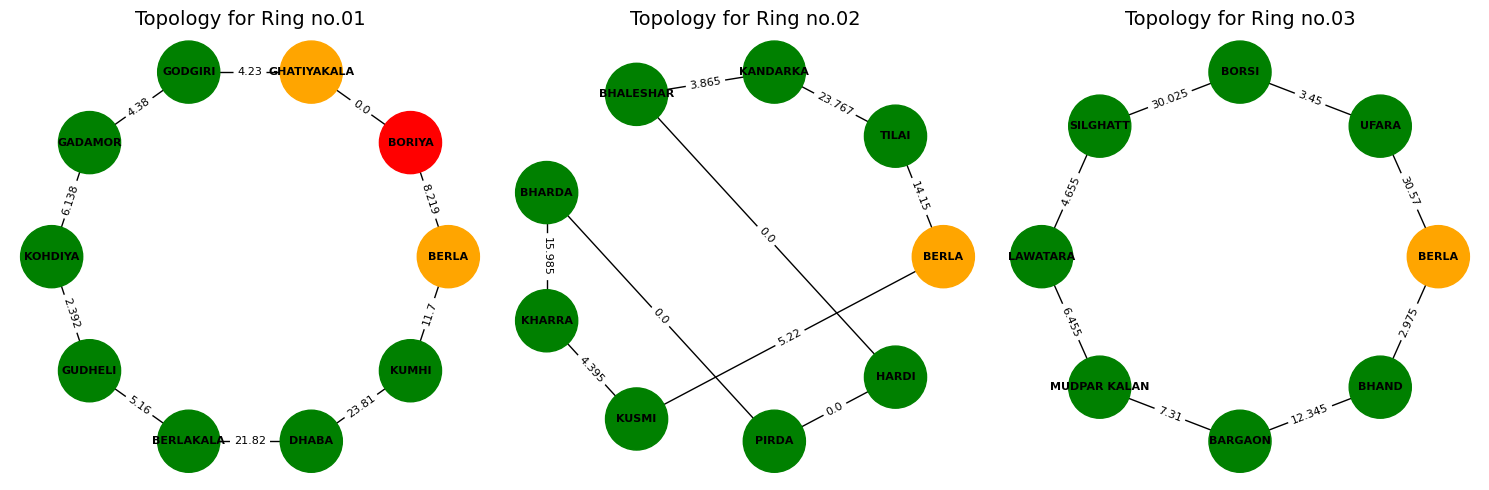

In [81]:
visualize_rings_legiblyand_impact(ips,data)

In [91]:
def find_common_physical_connections_from_files(logical_df, physical_connections_file, input_connections):


    # Load the data from CSV files

    physical_df = pd.read_csv(physical_connections_file)
    
    common_physical_connections = {}
    all_physical_segments = None
    
    for input_connection in input_connections:
         aend_name, bend_name = input_connection.split('-')
         print(aend_name)
         # Find the logical connection
         logical_connection = logical_df[((logical_df['aendname'] == aend_name) & (logical_df['bendname'] == bend_name)) |
                                          ((logical_df['aendname'] == bend_name) & (logical_df['bendname'] == aend_name))]
         
         if not logical_connection.empty:
             physical_segments_str = logical_connection['physicalsegments'].iloc[0]
          
             if isinstance(physical_segments_str, str) and physical_segments_str: #check if not empty and is not Nan value
                 physical_segments = set(int(segment.strip()) for segment in physical_segments_str.split(','))  # Convert to set

                 print(physical_segments)
                 if all_physical_segments is None:
                    all_physical_segments = physical_segments  # Initialize with the first set
                 else:
                    all_physical_segments &= physical_segments      
                 
    
    # all_physical_segments = set(all_physical_segments)

    if not all_physical_segments:
        return None
    
    # Find matching physical segments
    for segment_id in all_physical_segments:
         physical_connection = physical_df[physical_df['segmentid'] == segment_id]
         if not physical_connection.empty:
            common_physical_connections[segment_id] = physical_connection.to_dict(orient='records')[0]
         else:
            common_physical_connections[segment_id] = None
    return common_physical_connections

In [ ]:


physical_connections_file = 'topology_data_physical.csv'  # Replace with your file path
input_connections = ['KUMHI-BERLA', 'KHARRA-BHARDA','BARGAON-BHAND']


# List of fiber cuts

common_connections = find_common_physical_connections_from_files(
    data, physical_connections_file, input_connections
)

if common_connections:
    for segment_id, connection in common_connections.items():
        if connection:
            print(f"Common segment ID: {segment_id}")
            print("Physical Connection Details:")
            for key, value in connection.items():
               print(f"  {key}: {value}")
            print("-" * 30)
        else:
           print(f"Common segment ID: {segment_id}")
           print("No Physical Connection Details found")
else:
    print("No common segments found for the given logical connections.")

KUMHI
{128, 129, 130, 127}
KHARRA
{124, 125, 126, 127}
BARGAON
{128, 129, 126, 127}
Common segment ID: 127
Physical Connection Details:
  id: 1209
  ringname: BERLA_Blue
  ringnum: nan
  ringcolor: nan
  segmentid: 127
  aendname: KUMHI
  bendname: KHARRA
  isspur: 0
  isjc: 0
  aendid: 2584
  bendid: 2704
  aendip: 10.128.17.88
  bendip: 10.128.17.46
  color: nan
  logtime: 2024-12-31 14:25:42
  aendxy: -567;-475
  bendxy: -434;-538
  bypass: 0
  bypassgp: nan
  bypass_lrdata: nan
------------------------------


In [103]:
key = next(iter(common_connections))
physical_cut = f"{common_connections[key]['aendname']}-{common_connections[key]['bendname']}"
physical_cut

'KUMHI-KHARRA'

In [98]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def plot_topology(csv_file, isolated_nodes=None, fiber_cuts=None):
    """
    Plot the network topology from CSV with isolated nodes and fiber-cut edges highlighted in red.

    Args:
        csv_file (str): Path to the CSV file containing 'aendname', 'bendname', 'aendxy', 'bendxy'.
        isolated_nodes (list): List of node names that are isolated.
        fiber_cuts (list): List of edges in the format ["NodeA-NodeB", "NodeC-NodeD", ...].
    """
    if isolated_nodes is None:
        isolated_nodes = []
    if fiber_cuts is None:
        fiber_cuts = []

    df = pd.read_csv(csv_file)
    G = nx.Graph()
    pos = {}

    # Build the graph
    for _, row in df.iterrows():
        aend, bend = row['aendname'], row['bendname']
        aend_xy = tuple(map(int, row['aendxy'].split(';')))
        bend_xy = tuple(map(int, row['bendxy'].split(';')))

        G.add_node(aend)
        G.add_node(bend)
        G.add_edge(aend, bend)

        pos[aend] = aend_xy
        pos[bend] = bend_xy

    # Prepare edge list for fiber cuts
    # Convert "A-B" to a tuple (A, B) or (B, A) if the edge is reversed in the graph
    cut_edges = []
    for cut in fiber_cuts:
        a, b = cut.split('-')
        if G.has_edge(a, b):
            cut_edges.append((a, b))
        elif G.has_edge(b, a):
            cut_edges.append((b, a))

    # Node colors
    node_colors = []
    for node in G.nodes():
        node_colors.append('red' if node in isolated_nodes else 'lightblue')

    # Draw all nodes and edges
    plt.figure(figsize=(10, 8))
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=500,
        node_color=node_colors,
        edge_color='gray',
        font_size=8
    )

    # Highlight fiber-cut edges in red
    if cut_edges:
        nx.draw_networkx_edges(G, pos, edgelist=cut_edges, edge_color='red', width=2)

    plt.title("Network Topology (Red: Isolated Nodes & Fiber Cuts)")
    plt.show()

In [104]:
plot_topology('topology_data_physical.csv','BORIYA',physical_cut)

ValueError: not enough values to unpack (expected 2, got 1)

In [95]:
def get_connection_ips(connections, topology_df):
    """
    Return the IPs as tuples in aendip-bendip format regardless of the input order.

    Parameters:
        connections (list): List of connections in the format 'aendname-bendname'.
        topology_df (pd.DataFrame): DataFrame containing topology records with 
                                    columns 'aendname', 'bendname', 'aendip', 'bendip'.

    Returns:
        list: List of tuples in the format (aendip, bendip).
    """
    connection_ips = []
    for connection in connections:
        aendname, bendname = connection.split('-')
        aendip = get_ip_by_name(aendname, topology_df)
        bendip = get_ip_by_name(bendname, topology_df)
        if aendip and bendip:
            connection_ips.append((aendip, bendip))
    return connection_ips

In [97]:
get_connection_ips(input_connections,data)

[('10.128.17.88', '10.128.0.16'),
 ('10.128.17.46', '10.128.17.13'),
 ('10.128.17.7', '10.128.17.11')]

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


def identify_isolated_nodes(node_ip, fiber_cuts, topology_df):
    """
    Identify isolated nodes after a fiber cut or node power-off.

    Parameters:
        node_ip (str): The IP address of the node that is not reachable.
        fiber_cuts (list): List of tuples representing fiber cuts (e.g., [('10.128.0.1', '10.128.0.2')]).
        topology_df (pd.DataFrame): DataFrame containing topology records with 
                                    columns 'aendname', 'bendname', 'aendip', 'bendip'.

    Returns:
        list: A list of isolated node IP addresses.
    """
    # Create a graph
    G = nx.Graph()

    # Add edges to the graph
    for _, row in topology_df.iterrows():
        G.add_edge(row['aendip'], row['bendip'], weight=row['distance'])

    # Remove the node that is not reachable
    if node_ip in G:
        G.remove_node(node_ip)

    # Remove the edges corresponding to fiber cuts
    for cut in fiber_cuts:
        if G.has_edge(*cut):
            G.remove_edge(*cut)

    # Identify isolated nodes
    isolated_nodes = [node for node in G.nodes() if nx.is_isolate(G, node)]

    return isolated_nodes

# Example usage:
# Assuming you have imported pandas as pd and loaded topology_df from your CSV or database:

node_ip = "10.128.0.16"  # The IP address of the node that is not reachable
fiber_cuts =  # Example fiber cuts

isolated_nodes = identify_isolated_nodes(node_ip, fiber_cuts, data)
print("Isolated nodes:", isolated_nodes)

Isolated nodes: []


10.128.17.31 is down


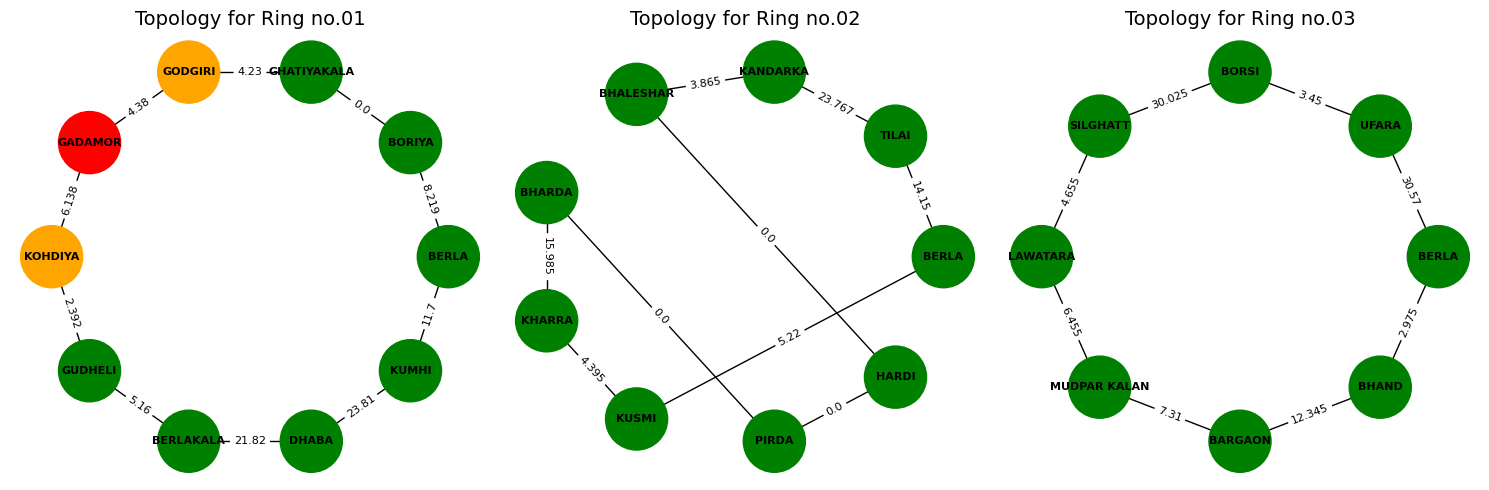

In [87]:
node_power_down = "gadamor"
ip = get_ip_by_name(node_power_down,data)
neighbours = get_neighbors_ip(node_power_down,data)
create_dummy_node_not_reachable_alarm(ip)
insert_link_down_alarms(neighbours,cursor)
last_checked_time = "2025-02-03 14:53:00"
ips=check_alarms_and_get_ips(last_checked_time)
visualize_rings_legiblyand_impact(ips,data)